In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import requests

# Data Wrangling

We're not interested in the Picture column, so we will drop it.

In [2]:
data = pd.read_csv('data/WinnersData.csv', index_col=0)
df = data.copy()
df.drop(columns=['Picture'], inplace=True)

From the data.info() output, we can see that all of the other columns have no missing values. However, we do know that the prize was not awarded in some years. We want to search for and remove those rows from the dataset.

In [3]:
mask = df['Laureate'].str.contains(r'Not awarded', regex=True)
print(df[mask])

    Year     Laureate      Country  Language(s)     Citation     Genre(s)
14  1914  Not awarded  Not awarded  Not awarded  Not awarded  Not awarded
19  1918  Not awarded  Not awarded  Not awarded  Not awarded  Not awarded
36  1935  Not awarded  Not awarded  Not awarded  Not awarded  Not awarded
41  1940  Not awarded  Not awarded  Not awarded  Not awarded  Not awarded
42  1941  Not awarded  Not awarded  Not awarded  Not awarded  Not awarded
43  1942  Not awarded  Not awarded  Not awarded  Not awarded  Not awarded
44  1943  Not awarded  Not awarded  Not awarded  Not awarded  Not awarded


In [4]:
df.drop(df[mask].index, axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)
df.to_csv("data/laureates.csv")

Because the data was sourced from Wikipedia, some of the text fields contain citations in brackets (like "[5]"). We remove these using a regular expression. Because this might create extra spaces, we will also strip leading and trailing whitespace from all text fields, and replace double spaces with single spaces.

In [5]:
df.replace(r'\[\d+\]', '', regex = True, inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip().str.replace(r'\s{2,}', ' ', regex=True)

We want each author to be associated with only one genre, the primary genre they are known for. For this reason, we select the first genre from the list in the Genre(s) column for each author.

In [6]:
import csv
genre = []
with open("data/laureates.csv", newline="", encoding="utf-8") as f:
    reader=csv.DictReader(f)
    for row in reader:
        Genre=row["Genre(s)"].title()
        first_genre = Genre.split(",")[0].strip()
        genre.append(first_genre)
df["Genre"] = pd.Series(genre)
df.drop(columns=["Genre(s)"], inplace=True)

Likewise, for visualization purposes we want each author to be associated with only one country. The Country column is updated manually, designating a primary country for each author. In selecting a country, we emphasized the country most associated with the author's literary career, rather than necessarily their country of birth.

In [7]:
df['Country'] = pd.Series(
    ["France","Germany","Norway","France","Spain","Poland","Italy","United Kingdom","Germany",
     "Sweden","Germany","Belgium","Germany","India","France","Sweden","Denmark","Denmark","Switzerland",
     "Norway","France","Spain","Ireland","Poland","United Kingdom","Italy","France","Norway",
     "Germany","United States","Sweden","United Kingdom","Russia","Italy","United States","France",
     "United States","Finland","Denmark","Chile","Germany","France","United Kingdom","United States",
     "United Kingdom","Sweden","France","United Kingdom","United States","Iceland","Spain","France","Russia",
     "Italy","France","Serbia","United States","Greece","France","Russia","Israel","Germany","Guatemala",
     "Japan","Ireland","Russia","Chile","Germany","Australia","Sweden","Sweden","Italy","United States",
     "Spain","Poland","Greece","Poland","Bulgaria","Colombia","United Kingdom","Czech Republic","France",
     "Nigeria","Russia","Egypt","Spain","Mexico","South Africa","Saint Lucia","United States","Japan",
     "Ireland","Poland","Italy","Portugal","Germany","China","United Kingdom","Hungary","South Africa",
     "Austria","United Kingdom","Turkey","United Kingdom","France","Romania","Peru","Sweden","China",
     "Canada","France","Belarus","United States","United Kingdom","Poland","Austria","United States",
     "Tanzania","France","Norway","South Korea","Hungary"]
)

In its raw form, the "Laureate" column contains the author's, full name, birth year and death year if applicable. We split this column into Name and Birth columns.

In [8]:
# Extract the laureate's birth year from the "Laureate" column
df["Birth"] = df["Laureate"].str.extract(r"(\d{4})").astype(int)

# Extract the laureate's name from the "Laureate" column
df["Name"] = df["Laureate"].str.extract(r"(.*) \(.*\)")
df["Name"] = df["Name"].str.strip()

To (roughly) calculate the age at which each author won the Nobel Prize, we subtract the Birth column from the Year column.

In [9]:
df["Age"] = df["Year"] - df["Birth"]

We also manually add a Gender column containing an 'M' for male authors and 'F' for female authors.

In [10]:
df["Gender"] = pd.Series(["M"]*df.shape[0])
# A list of all the years that only women were awarded
female_years = [1909, 1926, 1928, 1938,1945, 1991, 1993, 1996, 2004, 2007, 
                2009, 2013, 2015, 2018, 2020, 2022, 2024]
# Set gender to 'F' if the year is in female_years 
# or if the laureate is Nelly Sachs (who won in the same year as a man)
mask = df['Year'].isin(female_years) | df['Laureate'].str.contains('Sachs')
df.loc[mask, 'Gender'] = 'F'

For some of our visualizations we will want to group the data into decades. We create a Decade column using pd.cut() to bin the Year column.

In [11]:
bins = list(range(1900, 2040, 10))
labels = [f"{b}s" for b in bins[:-1]]
df['Decade'] = pd.cut(df['Year'], bins=bins, labels=labels, right=False)

We would like to associate a global region with each author based on their country. We use the country_converter package to map each country to a region as designated by the  MESSAGEix-GLOBIOM framework. The MESSAGE regions are:

1. NAM North America
2. LAM Latin America and the Caribbean
3. WEU Western Europe
4. EEU Central & Eastern Europe
5. FSU Former Soviet Union
6. MEA Middle East & North Africa
7. AFR Sub-Saharan Africa
8. CPA Centrally Planned Asia and China
9. SAS South Asia
10. PAS Other Pacific Asia
11. PAO Pacific OECD

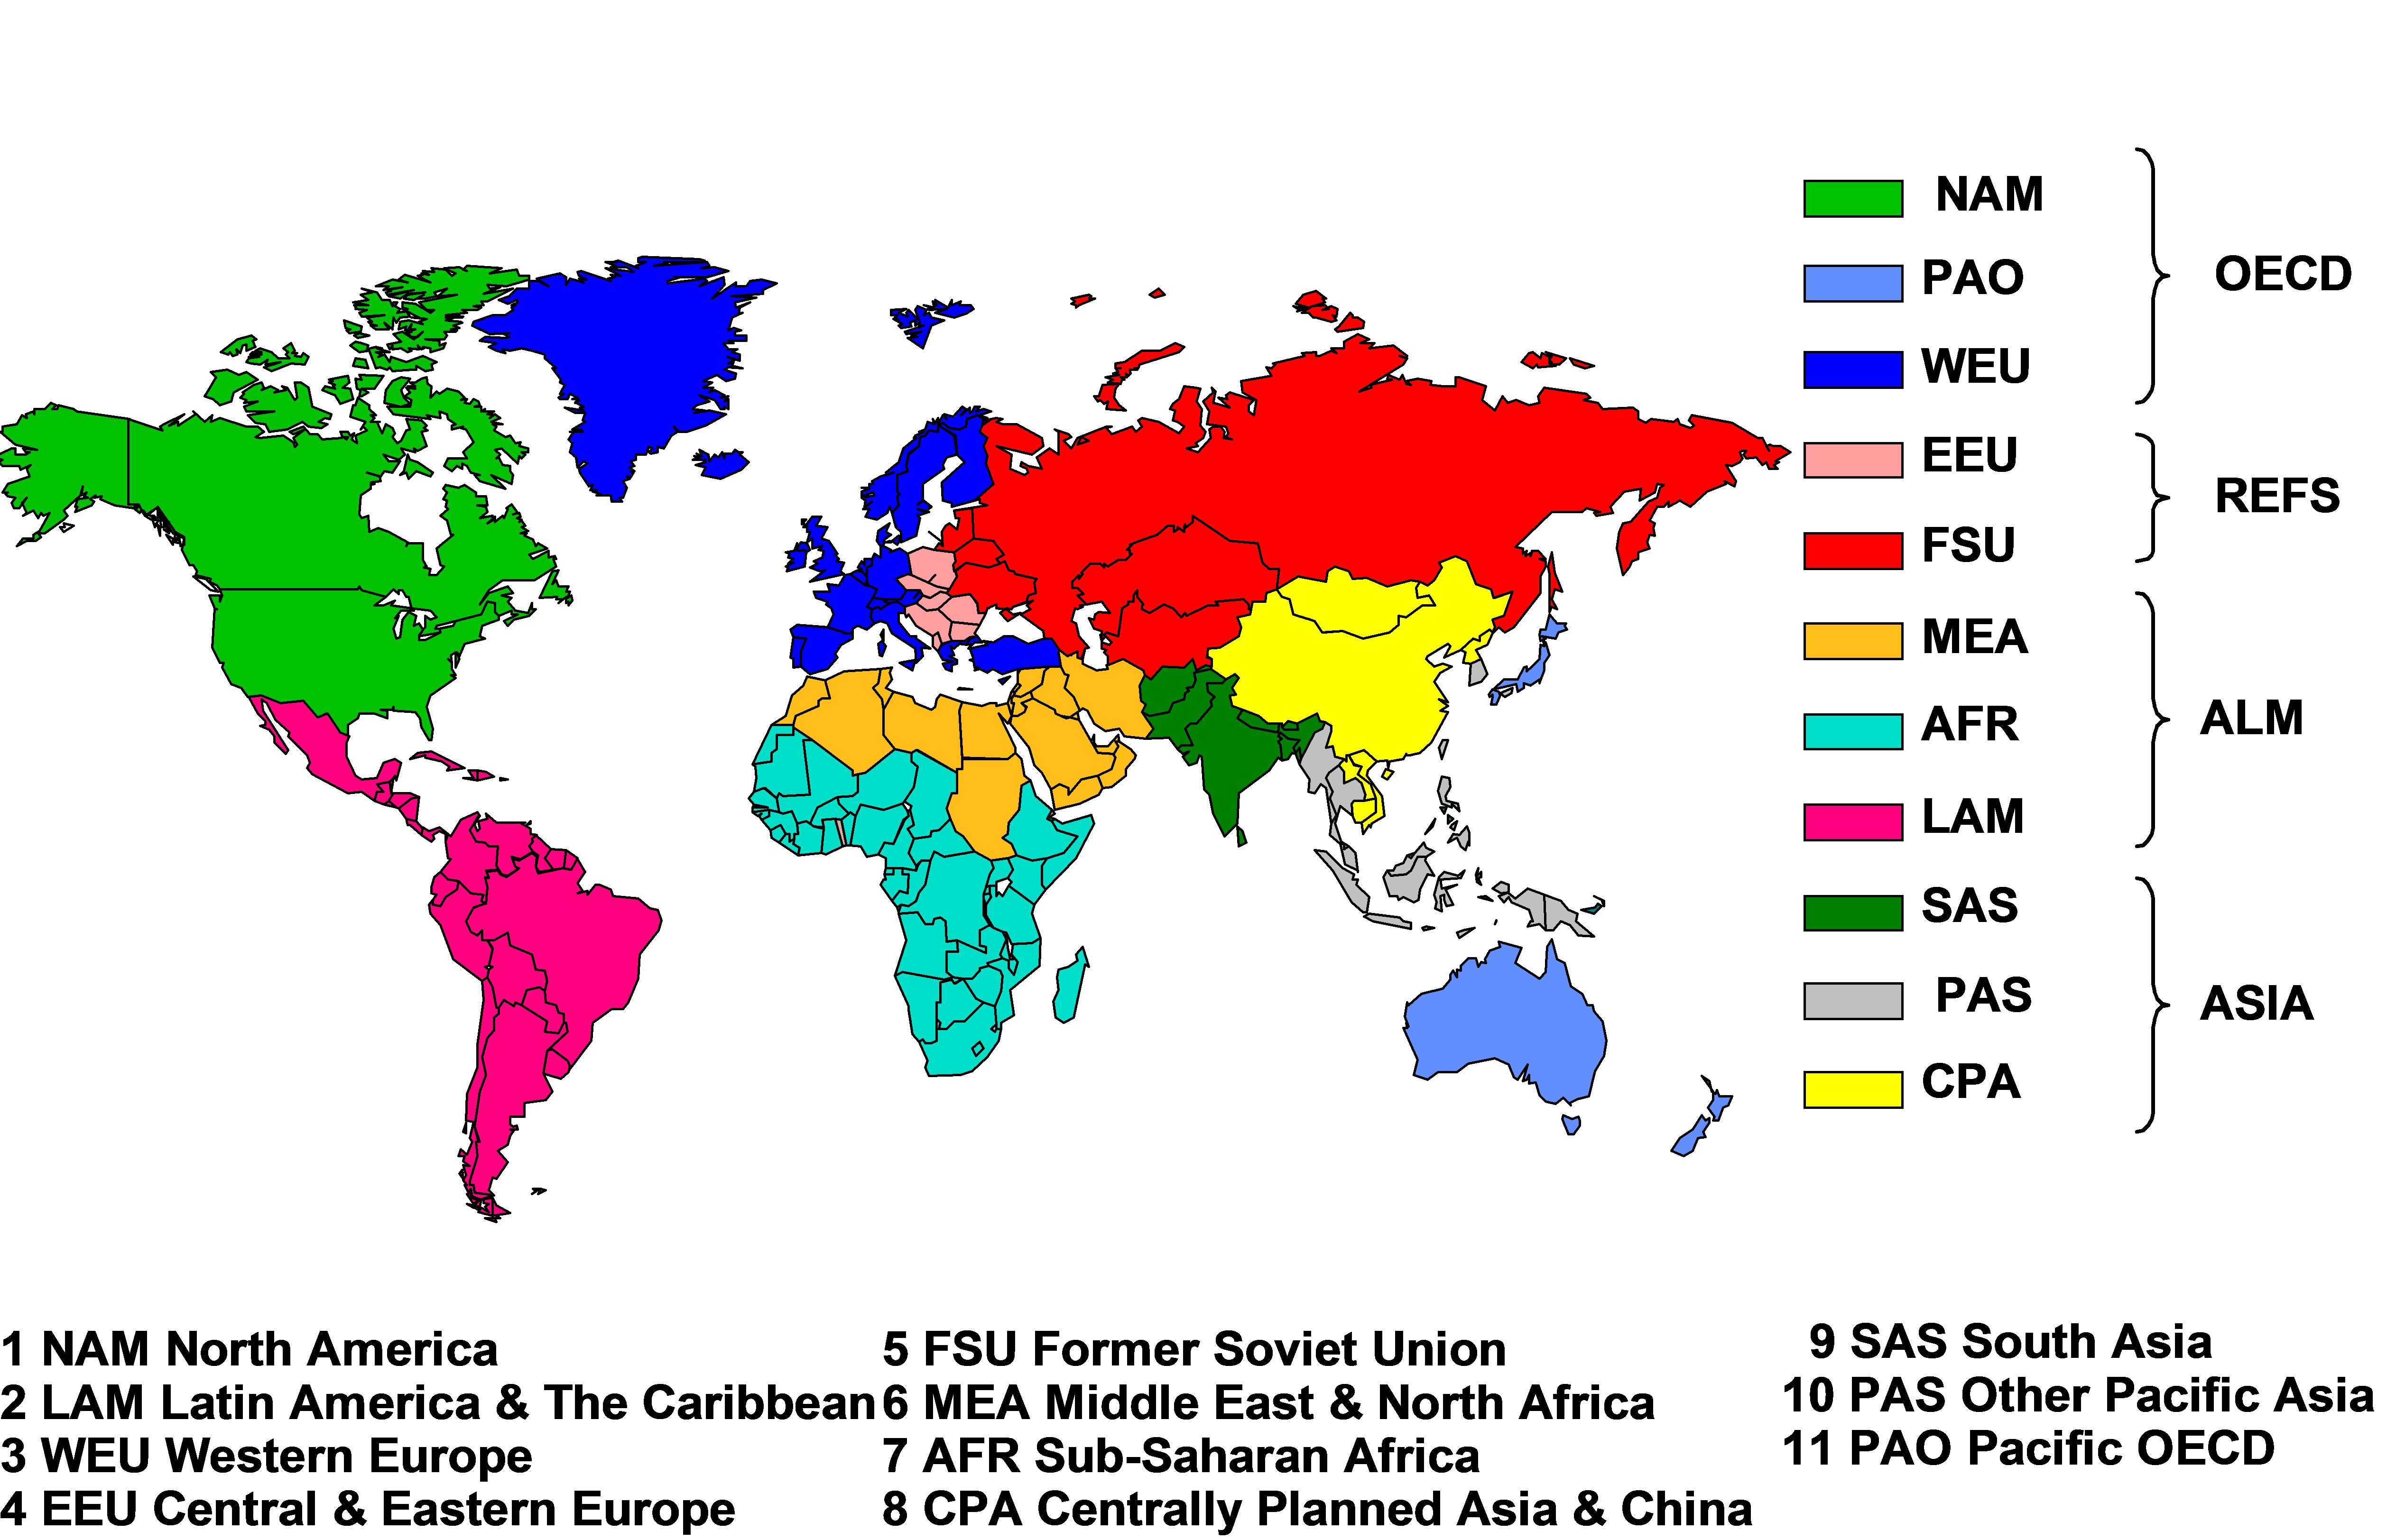

In [12]:
import country_converter as coco
cc = coco.CountryConverter()
df['Region'] = cc.convert(names=df['Country'], to='MESSAGE')
df['Region descriptions'] = df['Region'].map({
    'NAM': "North America",
    "LAC": "Latin America and the Caribbean",
    "WEU": "Western Europe",
    "EEU": "Central and Eastern Europe",
    "FSU": "Former Soviet Union",
    "MEA": "Middle East and North Africa",
    "AFR": "Sub-Saharan Africa",
    "CPA": "Centrally Planned Asia and China",
    "SAS": "South Asia",
    "PAS": "Other Pacific Asia",
    "PAO": "Pacific OECD"
})

For map visualization, we would like a column with the geometry of the MESSAGE region for each author. First we must create a GeoDataFrame with geometry matching these larger regions. Our starting point is a file containing geometry for all of the world's countries.

In [13]:
map_data = gpd.read_file("data/countries_shapefile/ne_110m_admin_0_countries.shp")

Convert the ISO codes to region codes matching the MESSAGE format:

In [14]:
cc = coco.CountryConverter()
map_data['MESSAGE'] = cc.convert(names=map_data['ISO_A3'], to='MESSAGE')
print(map_data['MESSAGE'].unique())

-99 not found in ISOnumeric
-99 not found in ISOnumeric
-99 not found in ISOnumeric
-99 not found in ISOnumeric
-99 not found in ISOnumeric


['PAS' 'AFR' 'MEA' 'NAM' 'FSU' 'LAC' 'not found' 'WEU' nan 'CPA' 'SAS'
 'EEU' 'PAO']


Remove rows where the conversion found no result.

In [15]:
notfound = map_data['MESSAGE'] == 'not found'
map_data = map_data[~notfound]
map_data.dropna(subset=["MESSAGE"], inplace=True)
map_data.shape

(170, 170)

Use dissolve to create new geometry matching the regions of the MESSAGE format, and export it to a csv.

In [17]:
regions = map_data.dissolve(by='MESSAGE', as_index=False)
regions.shape
try:
    regions.to_file('data/regions_shapefile')
except PermissionError:
    pass

c:\Users\tibbe\anaconda3\envs\isc4242\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 1366417754 of field POP_EST of feature 9 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


Merge laureates with Regions DataFrame to associate each author with the map geometry of their country, then select only the columns we need (the regions GeoDataFrame contains lots of columns unnecessary to our analysis.)

In [18]:
df = gpd.GeoDataFrame(pd.merge(left=df,
                  right=regions,
                  left_on='Region',
                  right_on='MESSAGE'))[['Year', 'Laureate', 'Country', 'Language(s)', 'Citation', 'Genre',
                                        'Birth', 'Name', 'Age', 'Gender', 'Decade', 'Region',
                                        'Region descriptions', 'geometry']]

We also clean the Citation column to remove punctuation marks for easier text analysis.

In [19]:
df["Citation"] = df["Citation"].str.replace(r'[",\.;]', '', regex=True)

We're ready to export the cleaned data to a separate .csv file.

In [20]:
df.to_csv('data/laureates_clean.csv', index=False)
try:
    df.to_file('data/geo_laureates')
except PermissionError:
    pass

C:\Users\tibbe\AppData\Local\Temp\ipykernel_39212\1263300882.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  df.to_file('data/geo_laureates')
c:\Users\tibbe\anaconda3\envs\isc4242\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Language(s)' to 'Language(s'
  ogr_write(
c:\Users\tibbe\anaconda3\envs\isc4242\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Region descriptions' to 'Region des'
  ogr_write(
c:\Users\tibbe\anaconda3\envs\isc4242\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 'in appreciation of his many-sided literary activities and especially of his dramatic works which are distinguished by a wealth of imagination and by a poetic fancy which reveals sometimes in the guise of a fairy tale a deep inspiration while in a mysterious way they appeal to the readers' own feelings and stimulate their imaginations' of field Citation 